# ppgtiAM classificaçãoPericias p1 cargaInicial-exploração-limpeza

Trabalho final da disciplina de Aprendizado de Máquina (prof Daniel Sabino) em 2026.1 (PPgTI/IMD/UFRN)

Membros:
- Bruno Silva
- Marlus Silva
- Selton Braz

Objetivo: *analisar a capacidade de classificação de processos judiciais quanto a necessidade de perícias médicas e indicação da área especializada, aplicando técnicas de aprendizado supervisionado e LLM.*

### Preparação e bibliotecas

In [ ]:
# executar qdo kernel local
%pip install pandas scipy seaborn matplotlib scikit-learn

In [1]:
# executar qdo kernel no google colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [44]:
import pandas as pd
from pathlib import Path
import numpy as np

pd.set_option('display.max_columns', None)

data_path = Path('df_metadadosPericias.csv')
if not data_path.exists():
    data_path = '/content/drive/MyDrive/Colab Notebooks/Doutorado/discAprendMáquina/[AprendMáquina] ProjetoFinal/df_metadadosPericias.csv'

df_metadadosPericias = pd.read_csv(data_path)
print(f'Dataset carregado com sucesso de {data_path}')
print(f'Formato do dataset: {df_metadadosPericias.shape}')

Dataset carregado com sucesso de /content/drive/MyDrive/Colab Notebooks/Doutorado/discAprendMáquina/[AprendMáquina] ProjetoFinal/df_metadadosPericias.csv
Formato do dataset: (165499, 26)


### Amostra dos dados

In [45]:
print('Amostra inicial do dataset:')
display(df_metadadosPericias.head())

Amostra inicial do dataset:


,index,id_processo_judicial,nr_processo_judicial,dt_primeira_distribuicao,in_tutela_antecipada,nm_juizado,ds_cidade,codigo_assunto,ds_assunto_judicial,ds_complemento_assunto_judicial,detalhe_assunto_1,detalhe_assunto_2,id_perito,ds_especialidade,ds_complemento_especialidade,ds_status_pericia,dt_cadastro_pericia,dt_realizacao_pericia,ds_tipo_documento,ds_extensao,dt_inclusao,vara,triagem_peticao,tamanho_texto,label_especialidade,requer_pericia
0,178672,475347,0501383-21.2019.4.05.8404,2019-04-24 00:00:00,N,12a. Vara Federal - Pau dos Ferros,Pau dos Ferros,195,Direito Previdenciário,Benefícios em Espécie,Auxílio-Doença Previdenciário,NaN,273713.0,Médico,Ortopedista,Pendente,2019-05-07 15:09:32.913625,NaN,Petição Inicial,pdf,2019-04-24 12:33:02.747616,8404,1,12943,Ortopedista,S
1,37083,256155,0501266-12.2014.4.05.8402,2014-05-26 00:00:00,N,9a. Vara Federal,Caicó,195,Direito Previdenciário,Benefícios em Espécie,Aposentadoria por Invalidez,NaN,173007.0,Médico,Clínico Geral,Realizada,2014-06-04 14:45:07.455382,2014-07-03 11:31:01.517090,Petição Inicial,pdf,2014-05-25 10:35:41.873462,8402,1,9262,Clínico Geral,S
2,1247,97537,0500434-21.2010.4.05.8401,2010-08-18 00:00:00,N,13a. Vara Federal,Mossoró,9985,Direito Administrativo e outras matérias do Di...,Servidor Público Civil,Sistema Remuneratório e Benefícios,Gratificações de Atividade,NaN,NaN,NaN,NaN,NaN,NaN,Petição Inicial,doc,2010-01-22 11:21:54.838634,8401,1,15203,SEM PERICIA,N
3,57386,286586,0501512-74.2015.4.05.8401,2015-03-23 00:00:00,N,13a. Vara Federal,Mossoró,195,Direito Previdenciário,Benefícios em Espécie,Auxílio-Doença Previdenciário,NaN,93707.0,Médico,Ortopedista,Cancelada,2015-03-25 15:03:50.695222,NaN,Petição Inicial,pdf,2015-03-21 17:32:41.491795,8401,1,10436,Ortopedista,S
4,197748,343815,0501892-57.2016.4.05.8403,2016-09-06 00:00:00,N,11a. Vara Federal - Açú,Açu,195,Direito Previdenciário,Benefícios em Espécie,Auxílio-Doença Previdenciário,NaN,245026.0,Médico,Clínico Geral,Realizada,2016-09-09 21:10:55.743076,2016-10-07 11:33:19.011700,Petição Inicial,doc,2016-09-06 11:28:42.119963,8403,1,7981,Assistente Social+Médico,S


Pela amostra apresentada do dataset algumas observações preliminares:

- atributos [`index`, `id_processo_judicial`, `nr_processo_judicial`] são identificadores únicos para a estrutura de dados >> **devem ser removidos da análise, exceto um para identificação da amostra**
- os atributos [`ds_tipo_documento`, `ds_extensao`, `dt_inclusao`, `tamanho_texto`] referem-se a dados sobre arquivos binários com inteiro teor das petições removidos da análise por algoritmos de classificação >> **devem ser removidos da análise**
- os atributos [`label_especialidade`, `requer_pericia`] são as classes deste dataset considerando o objetivo do trabalho de pesquisa


In [46]:
# removendo atributos identificados acima como desnecessários
df_metadadosPericias = df_metadadosPericias.drop(columns=['index','nr_processo_judicial', 'ds_tipo_documento', 'ds_extensao', 'dt_inclusao', 'tamanho_texto'])
print('Dataset com atributos removidos:')
display(df_metadadosPericias.head())
print('Formato do dataset após remoção de atributos:')
display(df_metadadosPericias.shape)

Dataset com atributos removidos:


,id_processo_judicial,dt_primeira_distribuicao,in_tutela_antecipada,nm_juizado,ds_cidade,codigo_assunto,ds_assunto_judicial,ds_complemento_assunto_judicial,detalhe_assunto_1,detalhe_assunto_2,id_perito,ds_especialidade,ds_complemento_especialidade,ds_status_pericia,dt_cadastro_pericia,dt_realizacao_pericia,vara,triagem_peticao,label_especialidade,requer_pericia
0,475347,2019-04-24 00:00:00,N,12a. Vara Federal - Pau dos Ferros,Pau dos Ferros,195,Direito Previdenciário,Benefícios em Espécie,Auxílio-Doença Previdenciário,NaN,273713.0,Médico,Ortopedista,Pendente,2019-05-07 15:09:32.913625,NaN,8404,1,Ortopedista,S
1,256155,2014-05-26 00:00:00,N,9a. Vara Federal,Caicó,195,Direito Previdenciário,Benefícios em Espécie,Aposentadoria por Invalidez,NaN,173007.0,Médico,Clínico Geral,Realizada,2014-06-04 14:45:07.455382,2014-07-03 11:31:01.517090,8402,1,Clínico Geral,S
2,97537,2010-08-18 00:00:00,N,13a. Vara Federal,Mossoró,9985,Direito Administrativo e outras matérias do Di...,Servidor Público Civil,Sistema Remuneratório e Benefícios,Gratificações de Atividade,NaN,NaN,NaN,NaN,NaN,NaN,8401,1,SEM PERICIA,N
3,286586,2015-03-23 00:00:00,N,13a. Vara Federal,Mossoró,195,Direito Previdenciário,Benefícios em Espécie,Auxílio-Doença Previdenciário,NaN,93707.0,Médico,Ortopedista,Cancelada,2015-03-25 15:03:50.695222,NaN,8401,1,Ortopedista,S
4,343815,2016-09-06 00:00:00,N,11a. Vara Federal - Açú,Açu,195,Direito Previdenciário,Benefícios em Espécie,Auxílio-Doença Previdenciário,NaN,245026.0,Médico,Clínico Geral,Realizada,2016-09-09 21:10:55.743076,2016-10-07 11:33:19.011700,8403,1,Assistente Social+Médico,S


Formato do dataset após remoção de atributos:


(165499, 20)

### Estrutura do dataset

In [47]:
print('Resumo estrutural:')
display(df_metadadosPericias.info())

Resumo estrutural:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165499 entries, 0 to 165498
Data columns (total 20 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   id_processo_judicial             165499 non-null  int64  
 1   dt_primeira_distribuicao         165499 non-null  object 
 2   in_tutela_antecipada             165499 non-null  object 
 3   nm_juizado                       165498 non-null  object 
 4   ds_cidade                        165498 non-null  object 
 5   codigo_assunto                   165499 non-null  int64  
 6   ds_assunto_judicial              165499 non-null  object 
 7   ds_complemento_assunto_judicial  165473 non-null  object 
 8   detalhe_assunto_1                164873 non-null  object 
 9   detalhe_assunto_2                48778 non-null   object 
 10  id_perito                        83939 non-null   float64
 11  ds_especialidade                 83939 non-nul

None

Considerando que os atributos de data poderiam ser avaliados quanto ao ciclo mais adequado ao processo judicial, ou uma avaliação sequencial do tempo, mas não seria tratado na forma de um atributo numérico, e  por considerar essa adequação demandaria uma análise por mais tempo não compatível com a entrega do trabalho, por simplificação, decidimos descartar.

In [48]:
# remover atributos baseados em data
df_metadadosPericias = df_metadadosPericias.drop(columns=['dt_primeira_distribuicao', 'dt_cadastro_pericia', 'dt_realizacao_pericia'])
print('Dataset com atributos removidos:')
display(df_metadadosPericias.head())
print('Formato do dataset após remoção de atributos:')
display(df_metadadosPericias.shape)

Dataset com atributos removidos:


,id_processo_judicial,in_tutela_antecipada,nm_juizado,ds_cidade,codigo_assunto,ds_assunto_judicial,ds_complemento_assunto_judicial,detalhe_assunto_1,detalhe_assunto_2,id_perito,ds_especialidade,ds_complemento_especialidade,ds_status_pericia,vara,triagem_peticao,label_especialidade,requer_pericia
0,475347,N,12a. Vara Federal - Pau dos Ferros,Pau dos Ferros,195,Direito Previdenciário,Benefícios em Espécie,Auxílio-Doença Previdenciário,NaN,273713.0,Médico,Ortopedista,Pendente,8404,1,Ortopedista,S
1,256155,N,9a. Vara Federal,Caicó,195,Direito Previdenciário,Benefícios em Espécie,Aposentadoria por Invalidez,NaN,173007.0,Médico,Clínico Geral,Realizada,8402,1,Clínico Geral,S
2,97537,N,13a. Vara Federal,Mossoró,9985,Direito Administrativo e outras matérias do Di...,Servidor Público Civil,Sistema Remuneratório e Benefícios,Gratificações de Atividade,NaN,NaN,NaN,NaN,8401,1,SEM PERICIA,N
3,286586,N,13a. Vara Federal,Mossoró,195,Direito Previdenciário,Benefícios em Espécie,Auxílio-Doença Previdenciário,NaN,93707.0,Médico,Ortopedista,Cancelada,8401,1,Ortopedista,S
4,343815,N,11a. Vara Federal - Açú,Açu,195,Direito Previdenciário,Benefícios em Espécie,Auxílio-Doença Previdenciário,NaN,245026.0,Médico,Clínico Geral,Realizada,8403,1,Assistente Social+Médico,S


Formato do dataset após remoção de atributos:


(165499, 17)

### Estatísticas do dataset

In [49]:
print('Estatísticas descritivas para colunas numéricas:')
display(df_metadadosPericias.describe(include='all'))

Estatísticas descritivas para colunas numéricas:


,id_processo_judicial,in_tutela_antecipada,nm_juizado,ds_cidade,codigo_assunto,ds_assunto_judicial,ds_complemento_assunto_judicial,detalhe_assunto_1,detalhe_assunto_2,id_perito,ds_especialidade,ds_complemento_especialidade,ds_status_pericia,vara,triagem_peticao,label_especialidade,requer_pericia
count,165499.000000,165499,165498,165498,165499.000000,165499,165473,164873,48778,83939.000000,83939,77090,83939,165499.000000,165499.0,165499,165499
unique,NaN,2,9,6,NaN,8,59,268,339,NaN,2,8,5,NaN,NaN,11,2
top,NaN,N,7a. Vara Federal,Natal,NaN,Direito Previdenciário,Benefícios em Espécie,Auxílio-Doença Previdenciário,Rural (Art. 48/51),NaN,Médico,Ortopedista,Realizada,NaN,NaN,SEM PERICIA,S
freq,NaN,133690,43139,84619,NaN,119492,112003,48226,8470,NaN,77090,24906,70238,NaN,NaN,81560,83939
mean,343205.470498,NaN,NaN,NaN,1743.708228,NaN,NaN,NaN,NaN,154820.148251,NaN,NaN,NaN,8401.125499,1.0,NaN,NaN
std,92186.776313,NaN,NaN,NaN,3467.545267,NaN,NaN,NaN,NaN,95972.000802,NaN,NaN,NaN,1.508930,0.0,NaN,NaN
min,12931.000000,NaN,NaN,NaN,14.000000,NaN,NaN,NaN,NaN,5.000000,NaN,NaN,NaN,8400.000000,1.0,NaN,NaN
25%,274302.500000,NaN,NaN,NaN,195.000000,NaN,NaN,NaN,NaN,79438.000000,NaN,NaN,NaN,8400.000000,1.0,NaN,NaN
50%,348817.000000,NaN,NaN,NaN,195.000000,NaN,NaN,NaN,NaN,140751.000000,NaN,NaN,NaN,8400.000000,1.0,NaN,NaN
75%,424940.500000,NaN,NaN,NaN,195.000000,NaN,NaN,NaN,NaN,233972.000000,NaN,NaN,NaN,8402.000000,1.0,NaN,NaN


Mais obserações extraídas:
- existem 10 especialidades médicas envolvidas e uma categoria é `sem pericia`
- no cadastro de peritos foram coletadas 8 especialidades (conf. `ds_complemento_especialidade`) mas foram indicadas 10 categoriasd de peritos (conf. `label_especialidade`) - provavelmente os atributos estão caracterizados entre aquele atributo anterior e o `ds_especialidade` (**conferir!**)

### Contagem de valores ausentes por coluna

In [50]:
print('Quantidade de valores nulos por coluna:')
display(df_metadadosPericias.isnull().sum())

print('Percentual de valores nulos por coluna:')
display((df_metadadosPericias.isnull().mean() * 100).round(2))

Quantidade de valores nulos por coluna:


,0
id_processo_judicial,0
in_tutela_antecipada,0
nm_juizado,1
ds_cidade,1
codigo_assunto,0
ds_assunto_judicial,0
ds_complemento_assunto_judicial,26
detalhe_assunto_1,626
detalhe_assunto_2,116721
id_perito,81560


Percentual de valores nulos por coluna:


,0
id_processo_judicial,0.00
in_tutela_antecipada,0.00
nm_juizado,0.00
ds_cidade,0.00
codigo_assunto,0.00
ds_assunto_judicial,0.00
ds_complemento_assunto_judicial,0.02
detalhe_assunto_1,0.38
detalhe_assunto_2,70.53
id_perito,49.28


Na avaliação de valores ausentes, podemos considerar:
- valores ausentes em [`nm_juizado`, `ds_cidade`] indicam falta de preenchimento ou carga original dos dados >> **remover linha**
- as ausências de valores em [`ds_complemento_assunto_judicial`, `detalhe_assunto_1`, `detalhe_assunto_2`] são dependentes do domínio, esses campos não são obrigatórios e dependem do atributo `ds_assunto_judicial`
- a ausência de valores em [`id_perito`, `ds_especialidade`, `ds_status_pericia`, `ds_cadastro_pericia`] ocorre após perícias no mínimo agendadas ou realizadas, nos casos em que não precisa de perícia ou não foram agendadas, não há esse preenchimento ainda, por isso valores nulosjá que só faz sentido preenchimento qdo seja necessário realizar perícia para aquele caso

In [51]:
# remover linha onde nm_juizado é nulo
df_metadadosPericias = df_metadadosPericias.dropna(subset=['nm_juizado', 'ds_cidade'])
print('Quantidade de valores nulos por coluna após remoção:')
display(df_metadadosPericias.isnull().sum())


Quantidade de valores nulos por coluna após remoção:


,0
id_processo_judicial,0
in_tutela_antecipada,0
nm_juizado,0
ds_cidade,0
codigo_assunto,0
ds_assunto_judicial,0
ds_complemento_assunto_judicial,26
detalhe_assunto_1,625
detalhe_assunto_2,116720
id_perito,81559


## Análise de Valores Nulos

Identificando a existência e a quantidade de valores nulos em cada coluna, calculando tanto a contagem absoluta quanto o percentual de nulos.


In [59]:
print('Iniciando a análise de valores nulos.')

null_counts = df_metadadosPericias.isnull().sum()

null_percentages = (df_metadadosPericias.isnull().sum() / len(df_metadadosPericias)) * 100

null_info = pd.DataFrame({
    'Contagem de Nulos': null_counts,
    'Percentual de Nulos (%)': null_percentages
})

null_info = null_info.sort_values(by='Percentual de Nulos (%)', ascending=False)

print("\nAnálise de Valores Nulos por Coluna:")
print(null_info[null_info['Contagem de Nulos'] > 0]) # Display only columns with nulls

print('\nAnálise de valores nulos concluída.')

Iniciando a análise de valores nulos.

Análise de Valores Nulos por Coluna:
                                 Contagem de Nulos  Percentual de Nulos (%)
detalhe_assunto_2                           116720                70.526532
ds_complemento_especialidade                 88408                53.419377
ds_status_pericia                            81559                49.280958
id_perito                                    81559                49.280958
ds_especialidade                             81559                49.280958
detalhe_assunto_1                              625                 0.377648
ds_complemento_assunto_judicial                 26                 0.015710

Análise de valores nulos concluída.


Aqui fica mais claro qual o impacto da quantidade de valores nulos no dataset, e forma absoluta e percentual, ajudando a avaliar quais métodos serão usados em seguida para tratar esses dados ausentes.

## Análise de Cardinalidade

Para colunas categóricas, determinando o número de valores únicos para identificar colunas com alta ou baixa cardinalidade.


In [61]:
print('Iniciando a análise de cardinalidade para colunas categóricas.')

cardinality_data = []

for col in df_metadadosPericias.columns:
    # Verificar se a coluna é do tipo 'object' (categórica)
    if df_metadadosPericias[col].dtype == 'object':
        unique_count = df_metadadosPericias[col].nunique() # Número de valores únicos
        percentage_unique = (unique_count / len(df_metadadosPericias)) * 100 # Porcentagem de valores únicos
        cardinality_data.append({
            'Coluna': col,
            'Valores Únicos': unique_count,
            'Percentual Único (%)': percentage_unique
        })

cardinality_df = pd.DataFrame(cardinality_data)

cardinality_df = cardinality_df.sort_values(by='Percentual Único (%)', ascending=False)

print("\nAnálise de Cardinalidade para Colunas Categóricas:")
print(cardinality_df)

print('\nAnálise de cardinalidade concluída.')

Iniciando a análise de cardinalidade para colunas categóricas.

Análise de Cardinalidade para Colunas Categóricas:
                             Coluna  Valores Únicos  Percentual Único (%)
6                 detalhe_assunto_2             339              0.204836
5                 detalhe_assunto_1             268              0.161935
4   ds_complemento_assunto_judicial              59              0.035650
10              label_especialidade              11              0.006647
1                        nm_juizado               9              0.005438
8      ds_complemento_especialidade               8              0.004834
3               ds_assunto_judicial               8              0.004834
2                         ds_cidade               6              0.003625
9                 ds_status_pericia               5              0.003021
0              in_tutela_antecipada               2              0.001208
7                  ds_especialidade               2              0.0012

## Matriz de Correlação

Calculando e visualizando a matriz de correlação entre as variáveis numéricas do dataset para identificar possíveis relações lineares.


Iniciando o cálculo e visualização da matriz de correlação.


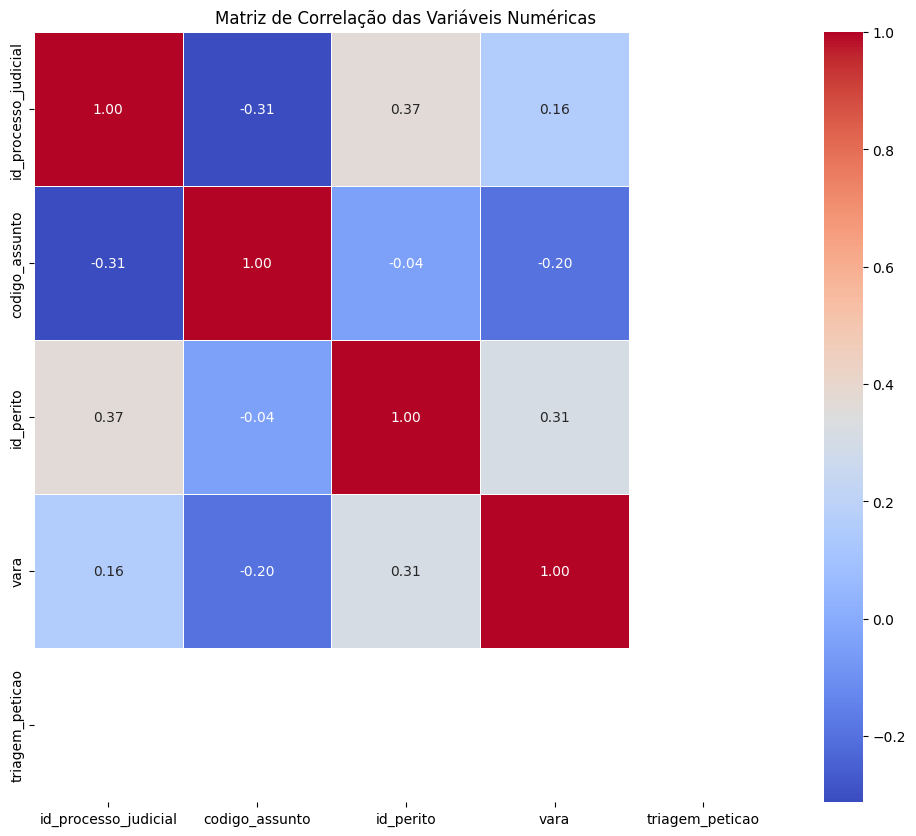


Cálculo e visualização da matriz de correlação concluídos.


In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

print('Iniciando o cálculo e visualização da matriz de correlação.')

# Selecione apenas as colunas numéricas do DataFrame `df`
numeric_df = df_metadadosPericias.select_dtypes(include=['number'])

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)

plt.title('Matriz de Correlação das Variáveis Numéricas')

plt.show()

print('\nCálculo e visualização da matriz de correlação concluídos.')

Com essa matriz de correlação foi possível identificar que entre as colunas numéricas há baixa correlação, com resultados numéricos entre 0,04 e 0,31 - indicando baixa correlação.

## Identificação de Outliers

Realizando uma identificação inicial de outliers das variáveis numéricas selecionadas utilizando box plots.


Iniciando a identificação de outliers com box plots.


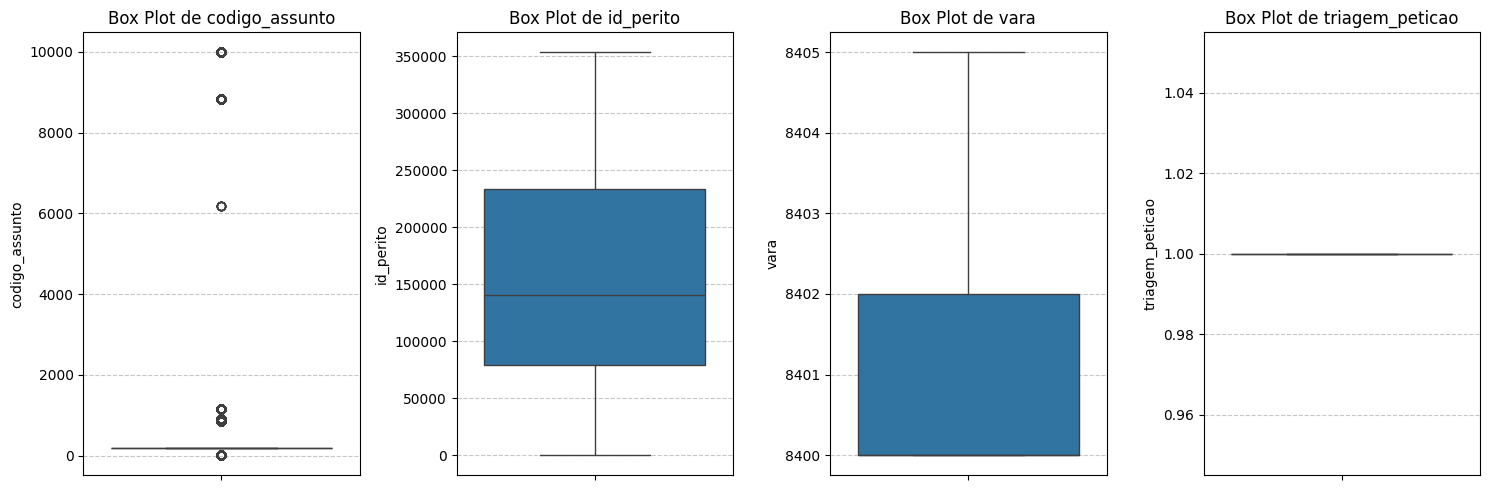


Identificação de outliers concluída para as colunas selecionadas.


In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

print('Iniciando a identificação de outliers com box plots.')

selected_numerical_cols = ['codigo_assunto', 'id_perito', 'vara', 'triagem_peticao']

plt.figure(figsize=(15, 5)) # Ajusta o tamanho da figura para acomodar múltiplos plots

for i, col in enumerate(selected_numerical_cols):
    plt.subplot(1, len(selected_numerical_cols), i + 1) # Cria subplots para cada coluna
    sns.boxplot(y=df_metadadosPericias[col])
    plt.title(f'Box Plot de {col}')
    plt.ylabel(col)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

print('\nIdentificação de outliers concluída para as colunas selecionadas.')

Para os atributos numéricos onde há alguma variação maior de valores, observa-se que não há grande variação dos valores, exceto para o atributo codigo_assunto o que indica a necessidade de tratar as dispersões nesse atributo.



---



## Distribuições

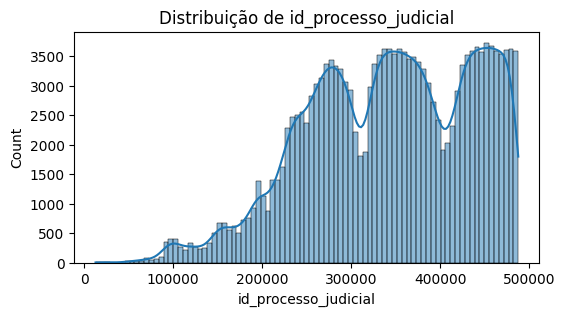

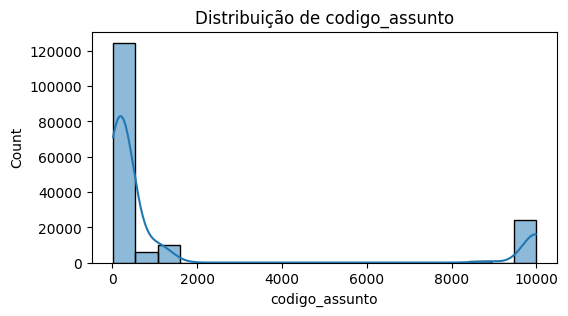

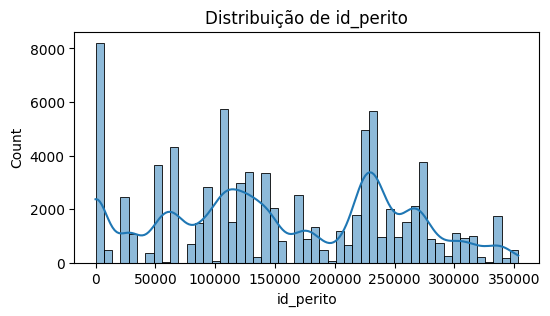

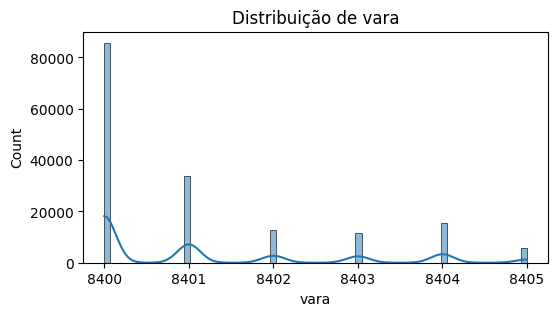

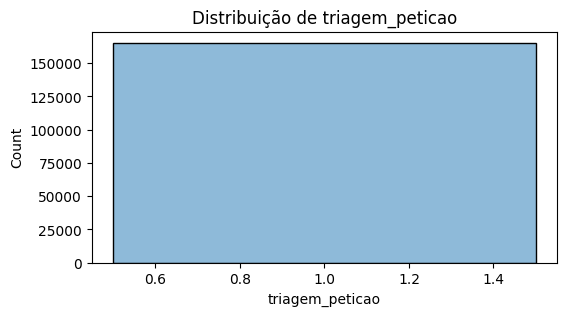

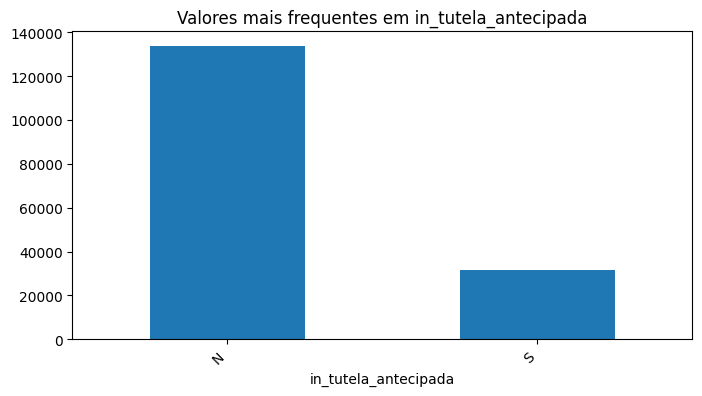

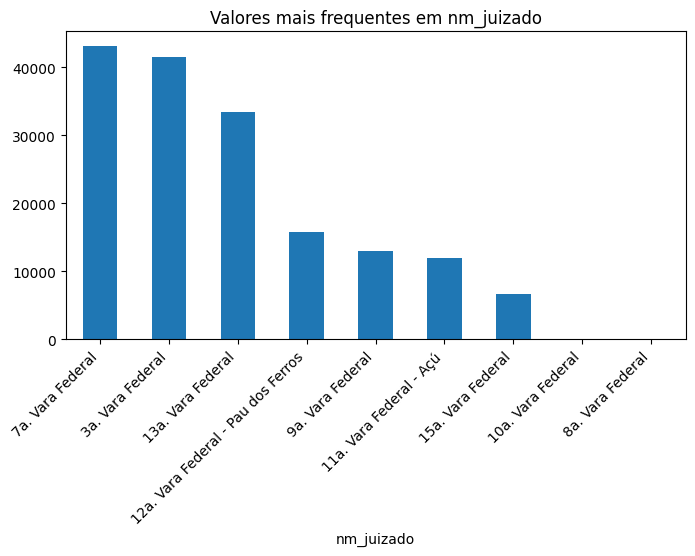

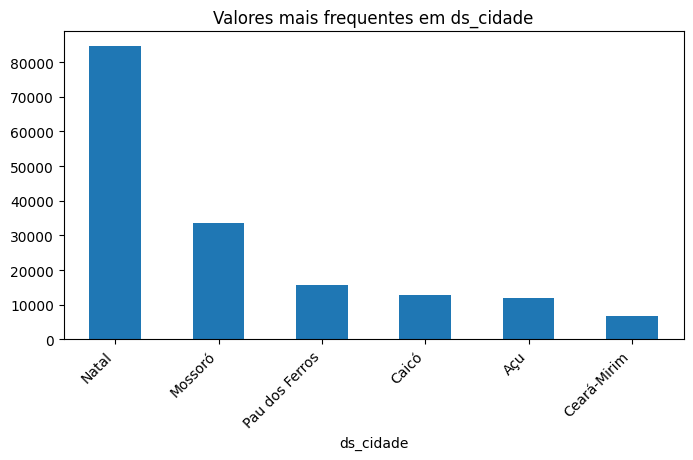

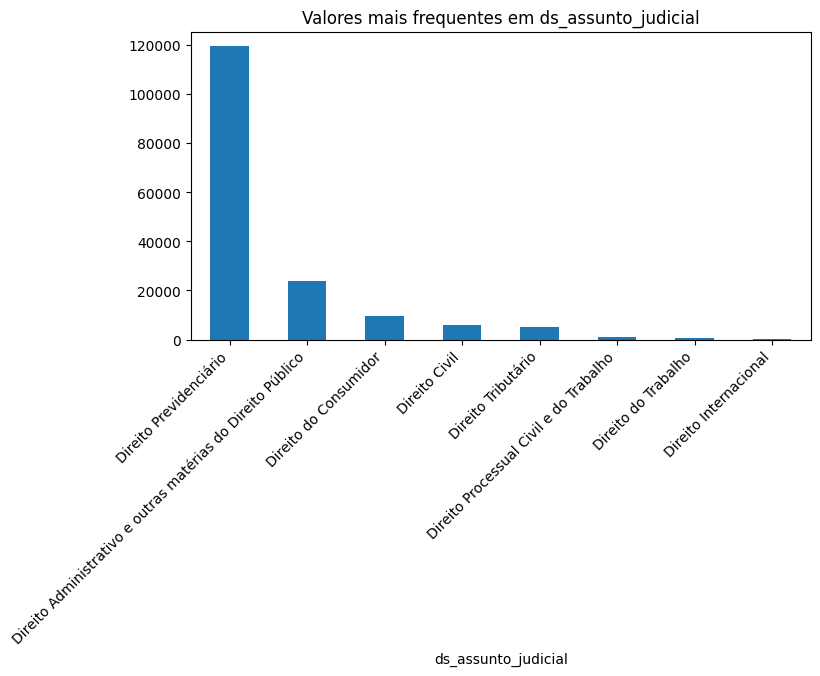

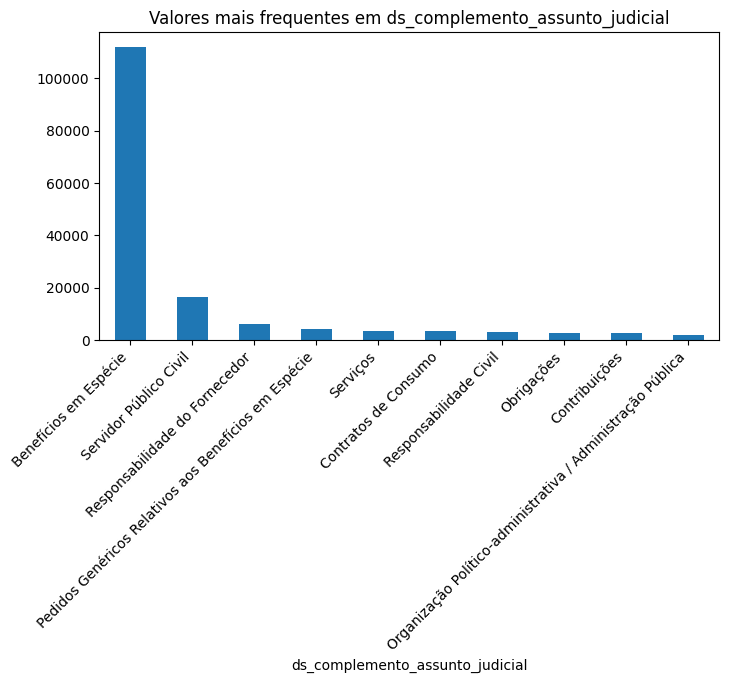

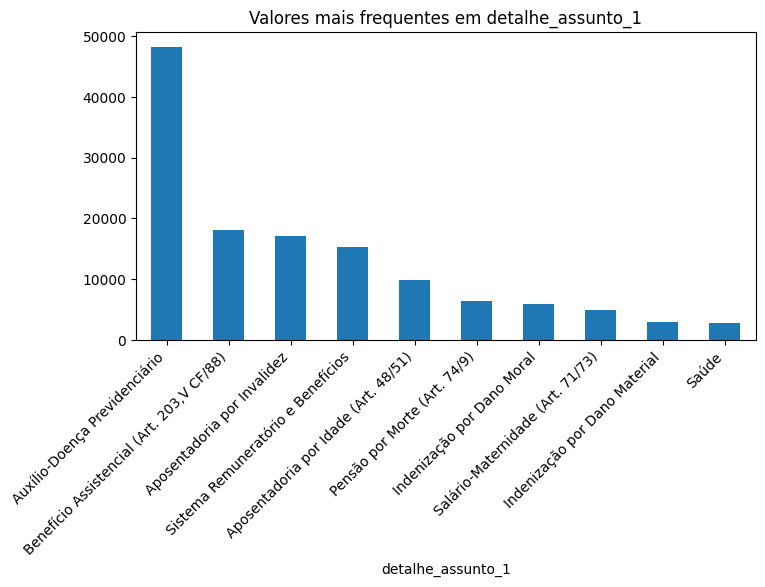

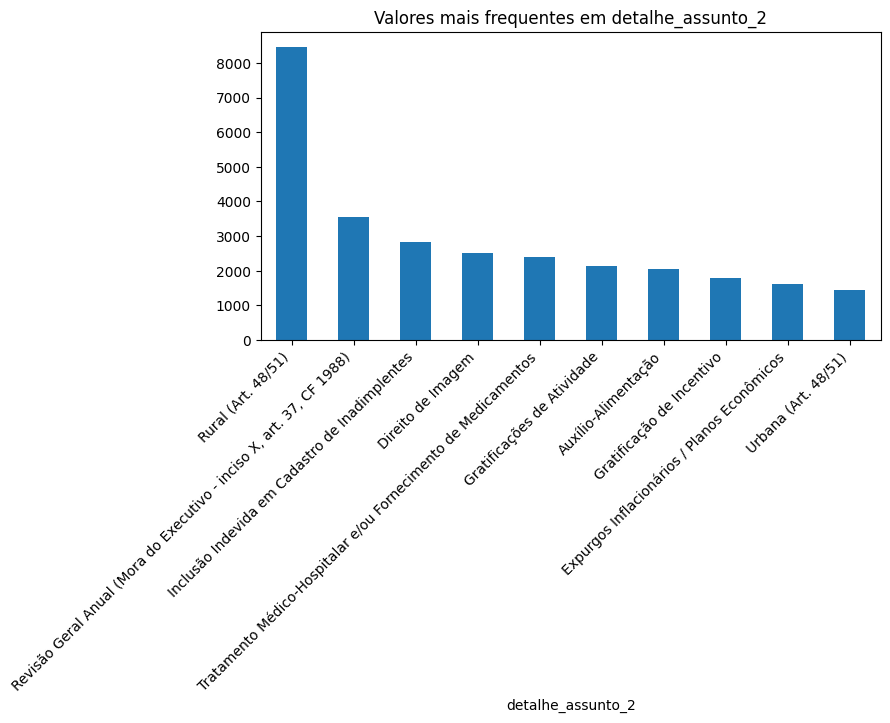

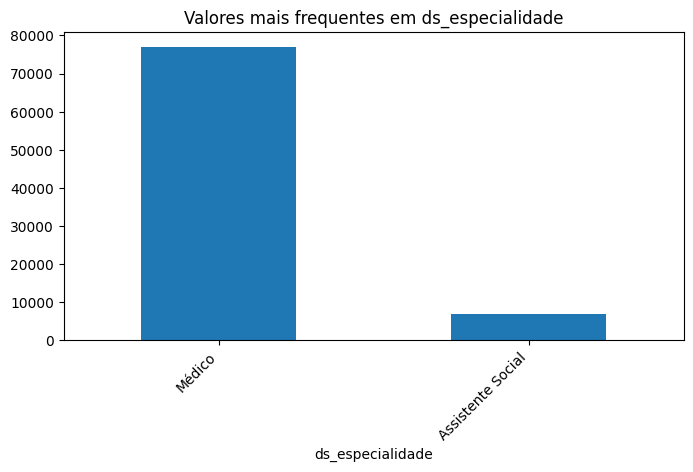

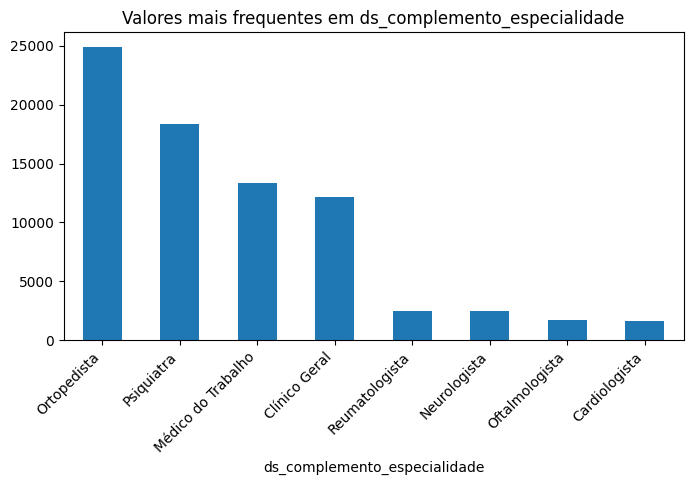

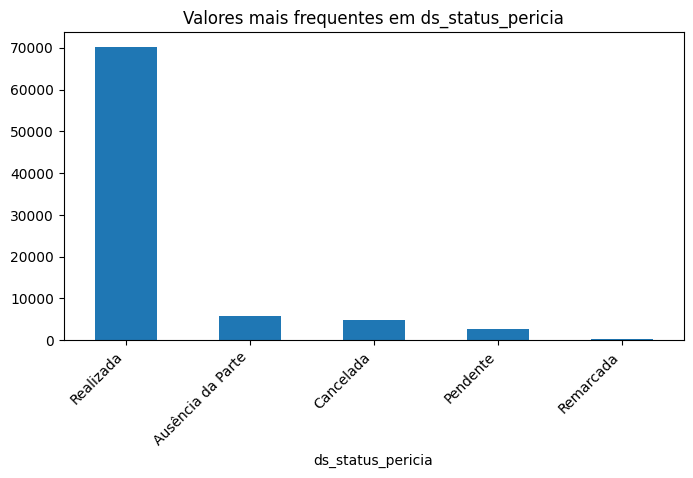

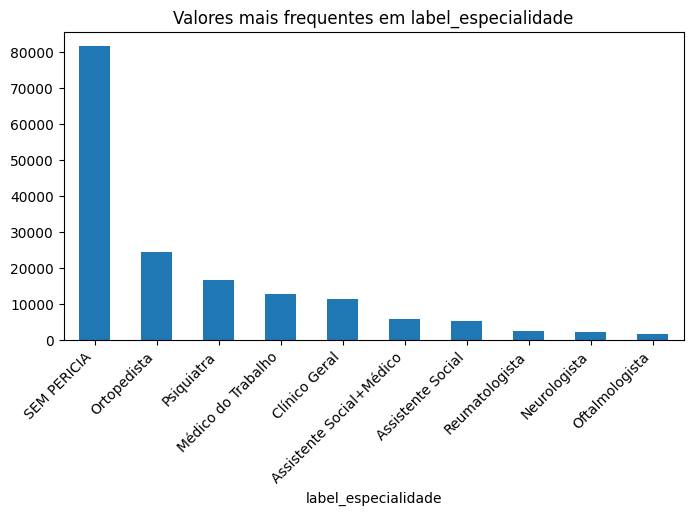

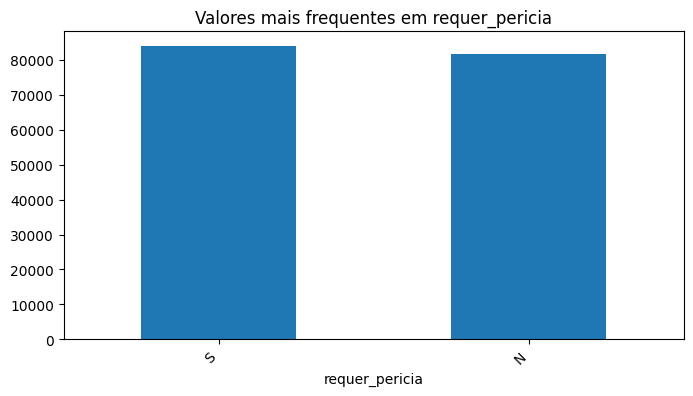

In [65]:
for col in numeric_cols:
    plt.figure(figsize=(6, 3))
    sns.histplot(df_metadadosPericias[col].dropna(), kde=True)
    plt.title(f'Distribuição de {col}')
    plt.show()

for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    df_metadadosPericias[col].value_counts().head(10).plot(kind='bar')
    plt.title(f'Valores mais frequentes em {col}')
    plt.xticks(rotation=45, ha='right')
    plt.show()

## Tratamento de dados

### Preenchendo dados ausentes

In [66]:
print('Iniciando o tratamento de valores não presentes.')

columns_to_fill = [
    'id_perito',
    'ds_especialidade',
    'ds_complemento_especialidade',
    'ds_status_pericia',
    'detalhe_assunto_2',
    'detalhe_assunto_1',
    'ds_complemento_assunto_judicial'
]

for col in columns_to_fill:
    if df_metadadosPericias[col].dtype in ['float64', 'int64']:
        # Preencher valores numéricos nulos com 0.0
        df_metadadosPericias[col] = df_metadadosPericias[col].fillna(0.0)
        print(f"Valores nulos na coluna '{col}' (numérica) preenchidos com 0.0")
    elif df_metadadosPericias[col].dtype == 'object':
        # Preencher valores categóricos nulos com 'não se aplica'
        df_metadadosPericias[col] = df_metadadosPericias[col].fillna('não se aplica')
        print(f"Valores nulos na coluna '{col}' (categórica) preenchidos com 'não se aplica'")
    else:
        print(f"Coluna '{col}' não é numérica nem categórica, nenhum tratamento aplicado.")

print("\nVerificação final de valores nulos nas colunas tratadas:")
print(df_metadadosPericias[columns_to_fill].isnull().sum())

print('\nTratamento de valores não presentes concluído.')

Iniciando o tratamento de valores não presentes.
Valores nulos na coluna 'id_perito' (numérica) preenchidos com 0.0
Valores nulos na coluna 'ds_especialidade' (categórica) preenchidos com 'não se aplica'
Valores nulos na coluna 'ds_complemento_especialidade' (categórica) preenchidos com 'não se aplica'
Valores nulos na coluna 'ds_status_pericia' (categórica) preenchidos com 'não se aplica'
Valores nulos na coluna 'detalhe_assunto_2' (categórica) preenchidos com 'não se aplica'
Valores nulos na coluna 'detalhe_assunto_1' (categórica) preenchidos com 'não se aplica'
Valores nulos na coluna 'ds_complemento_assunto_judicial' (categórica) preenchidos com 'não se aplica'

Verificação final de valores nulos nas colunas tratadas:
id_perito                          0
ds_especialidade                   0
ds_complemento_especialidade       0
ds_status_pericia                  0
detalhe_assunto_2                  0
detalhe_assunto_1                  0
ds_complemento_assunto_judicial    0
dtype: in

In [67]:
print('Exibindo as informações do DataFrame após o tratamento dos valores nulos:')
df_metadadosPericias.info()

Exibindo as informações do DataFrame após o tratamento dos valores nulos:
<class 'pandas.core.frame.DataFrame'>
Index: 165498 entries, 0 to 165498
Data columns (total 17 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   id_processo_judicial             165498 non-null  int64  
 1   in_tutela_antecipada             165498 non-null  object 
 2   nm_juizado                       165498 non-null  object 
 3   ds_cidade                        165498 non-null  object 
 4   codigo_assunto                   165498 non-null  int64  
 5   ds_assunto_judicial              165498 non-null  object 
 6   ds_complemento_assunto_judicial  165498 non-null  object 
 7   detalhe_assunto_1                165498 non-null  object 
 8   detalhe_assunto_2                165498 non-null  object 
 9   id_perito                        165498 non-null  float64
 10  ds_especialidade                 165498 non-null  object 
 

## Verificação de Linhas Duplicadas

In [68]:
print('Iniciando a verificação de linhas duplicadas.')

duplicate_rows = df_metadadosPericias.duplicated().sum()

print(f"Número de linhas duplicadas no DataFrame: {duplicate_rows}")

Iniciando a verificação de linhas duplicadas.
Número de linhas duplicadas no DataFrame: 0


## Transformação Count Encoding

Aplicando Count Encoding aos atributos categóricos selecionados do DataFrame para convertê-los em uma representação numérica baseada na frequência de cada categoria.

In [69]:
print('Iniciando a transformação Count Encoding.')

df_count_encoded = df_metadadosPericias.copy()

# Identificar colunas categóricas para Count Encoding
# Excluímos 'nr_processo_judicial' pois é um identificador único
categorical_cols_for_count_encoding = [
    'in_tutela_antecipada',
    'nm_juizado',
    'ds_cidade',
    'codigo_assunto',
    'ds_assunto_judicial',
    'ds_complemento_assunto_judicial',
    'detalhe_assunto_1',
    'detalhe_assunto_2',
    'id_perito',
    'ds_especialidade',
    'ds_complemento_especialidade',
    'ds_status_pericia',
    'vara',
    'triagem_peticao',
    'label_especialidade',
    'requer_pericia'
]

# Aplicar Count Encoding
for col in categorical_cols_for_count_encoding:
    count_map = df_count_encoded[col].value_counts().to_dict()
    df_count_encoded[col + '_count'] = df_count_encoded[col].map(count_map)
    # Remover a coluna original após a criação da coluna de contagem
    df_count_encoded = df_count_encoded.drop(columns=[col])

print(f"DataFrame original tinha {df_metadadosPericias.shape[1]} colunas.")
print(f"DataFrame após Count Encoding tem {df_count_encoded.shape[1]} colunas.")

print('\nPrimeiras linhas do DataFrame com Count Encoding:')
display(df_count_encoded.head())

Iniciando a transformação Count Encoding.
DataFrame original tinha 17 colunas.
DataFrame após Count Encoding tem 17 colunas.

Primeiras linhas do DataFrame com Count Encoding:


,id_processo_judicial,in_tutela_antecipada_count,nm_juizado_count,ds_cidade_count,codigo_assunto_count,ds_assunto_judicial_count,ds_complemento_assunto_judicial_count,detalhe_assunto_1_count,detalhe_assunto_2_count,id_perito_count,ds_especialidade_count,ds_complemento_especialidade_count,ds_status_pericia_count,vara_count,triagem_peticao_count,label_especialidade_count,requer_pericia_count
0,475347,133690,15764,15764,119492,119492,112003,48226,116720,330,77090,24906,2789,15651,165498,24257,83939
1,256155,133690,12954,12954,119492,119492,112003,17171,116720,809,77090,12142,70238,12812,165498,11446,83939
2,97537,133690,33377,33527,24008,24008,16444,15377,2121,81559,81559,88408,81559,33722,165498,81559,81559
3,286586,133690,33377,33527,119492,119492,112003,48226,116720,2804,77090,24906,4906,33722,165498,24257,83939
4,343815,133690,11968,11968,119492,119492,112003,48226,116720,848,77090,12142,70238,11753,165498,5836,83939


## Normalização de Dados (MinMaxScaler)

Aplicando o MinMaxScaler para normalizar as colunas numéricas do DataFrame `df_count_encoded`, escolhido por sua menor cardinalidade

In [70]:
print('Iniciando a normalização de dados com MinMaxScaler.')

from sklearn.preprocessing import MinMaxScaler

df_normalized = df_count_encoded.copy()

# Excluindo 'nr_processo_judicial' se for um identificador e não uma feature numérica a ser escalada
numerical_cols_for_normalization = df_normalized.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'nr_processo_judicial' in numerical_cols_for_normalization:
    numerical_cols_for_normalization.remove('nr_processo_judicial')

scaler = MinMaxScaler()

df_normalized[numerical_cols_for_normalization] = scaler.fit_transform(df_normalized[numerical_cols_for_normalization])

print('\nPrimeiras 5 linhas do DataFrame normalizado:')
display(df_normalized.head())

print('\nNormalização de dados concluída.')

Iniciando a normalização de dados com MinMaxScaler.

Primeiras 5 linhas do DataFrame normalizado:


,id_processo_judicial,in_tutela_antecipada_count,nm_juizado_count,ds_cidade_count,codigo_assunto_count,ds_assunto_judicial_count,ds_complemento_assunto_judicial_count,detalhe_assunto_1_count,detalhe_assunto_2_count,id_perito_count,ds_especialidade_count,ds_complemento_especialidade_count,ds_status_pericia_count,vara_count,triagem_peticao_count,label_especialidade_count,requer_pericia_count
0,0.974073,1.0,0.364363,0.116711,1.000000,1.000000,1.00000,1.000000,1.000000,0.004034,0.940182,0.267988,0.031846,0.123086,0.0,0.283492,1.0
1,0.512348,1.0,0.299115,0.080664,1.000000,1.000000,1.00000,0.356039,1.000000,0.009907,0.940182,0.120853,0.860855,0.087570,0.0,0.123303,1.0
2,0.178221,1.0,0.773330,0.344579,0.200864,0.200864,0.14681,0.318839,0.018163,1.000000,1.000000,1.000000,1.000000,0.349154,0.0,1.000000,0.0
3,0.576451,1.0,0.773330,0.344579,1.000000,1.000000,1.00000,1.000000,1.000000,0.034368,0.940182,0.267988,0.057866,0.349154,0.0,0.283492,1.0
4,0.697003,1.0,0.276221,0.068015,1.000000,1.000000,1.00000,1.000000,1.000000,0.010385,0.940182,0.120853,0.860855,0.074322,0.0,0.053155,1.0



Normalização de dados concluída.


## Checkpoint: Exportação de dados para CSV

In [72]:

df_normalized.to_csv('/content/drive/MyDrive/Colab Notebooks/Doutorado/discAprendMáquina/[AprendMáquina] ProjetoFinal/norm_df_metadadosPericias.csv', index=False)
print('Checkpoint salvo em norm_df_metadadosPericias.csv')

Checkpoint salvo em norm_df_metadadosPericias.csv
